# Test code

### Import of librabries

In [3]:
import sys
!{sys.executable} -m pip install gurobipy

In [4]:
import json
import os
import networkx as nx
import time as time_setting

Computation of the split coefficients

In [5]:
def buildNxGraph(net, V):
    G = nx.DiGraph()
    G.add_nodes_from(V)
    for link in net["links"]:
        G.add_edge(link["from"], link["to"], weight=link["metric"])
    return G

def computeSplitCoef(pairs, A, T, V, q_arc, net):
    """Reference (slow) ECMP split-coefficient computation. Equivalent
    to computeSplitCoefFast but uses NetworkX. Kept for cross-checking."""
    G = buildNxGraph(net, V)
    r = {}

    for time in T:
        G_t = G.copy()
        G_t.remove_edges_from(q_arc.get(time, []))

        # dist*(i, j) for every pair (i, j) - forward.
        shortest_dist = dict(nx.all_pairs_dijkstra_path_length(G_t, weight="weight"))
        # dist*(v, j) by running Dijkstra on the REVERSED graph from j.
        # In the reversed graph, dist_rev[j][v] = dist_forward(v, j).
        dist_rev = dict(nx.all_pairs_dijkstra_path_length(G_t.reverse(), weight="weight"))

        for (i, j) in pairs:
            if j not in shortest_dist.get(i, {}):
                continue
            dij = shortest_dist[i][j]
            shortest_dist_i = shortest_dist[i]

            # FG(i, j) = arcs (u, v) such that
            #   dist*(i, u) + w(u, v) + dist*(v, j) == dist*(i, j)
            FGList = []
            for (u, v, w) in G_t.edges(data="weight"):
                d_iu = shortest_dist_i.get(u)
                if d_iu is None:
                    continue
                d_vj = dist_rev.get(j, {}).get(v)
                if d_vj is None:
                    continue
                if abs(d_iu + w + d_vj - dij) < 1e-9:
                    FGList.append((u, v))

            if not FGList:
                continue

            FG = nx.DiGraph()
            FG.add_nodes_from(V)
            FG.add_edges_from(FGList)

            # ECMP forward pass: nodes processed in increasing dist*(i, .) order.
            flow = {node: 0.0 for node in V}
            flow[i] = 1.0
            order = sorted(
                (u for u in FG.nodes() if u in shortest_dist_i),
                key=lambda u: shortest_dist_i[u]
            )

            for u in order:
                if u == j:
                    continue
                out = list(FG.out_edges(u))
                if not out:
                    continue
                split = flow[u] / len(out)
                for _, v in out:
                    r[(i, j, u, v, time)] = r.get((i, j, u, v, time), 0.0) + split
                    flow[v] += split
    return r


Creation of the json output

In [6]:
def buildPath(segment_path, sd, td):
    if not segment_path :
        return []
    
    # Dictionary from i to j
    next_node = {i: j for (i, j) in segment_path}
    current = sd
    waypoints = []
    # Record visited nodes for cycles
    visited = set()

    while current != td:
        if current in visited:
            print(f"buildPath: Cycle detected at node {current}, unsing direct path")
            # Fall back to direct path (no waypoints) 
            return []
        visited.add(current)

        next = next_node.get(current)
        if next is None:
            print("buildPath Error : next is None, using direct path")
            return []
        if next != td:
            waypoints.append(next)
        current = next
    return waypoints


Algorithms and heuristics

#### Heuristic helpers (load eval, lex objective, budget cost)

In [7]:
# ============================================================
# Heuristic helpers - shared between H1, H2 and the pipeline
# ============================================================

def precomputeSegArcs(r):
    """For each segment (i,j) at time t, list of (arc, r_value) pairs (only the non-zero ones).
    This allows fast incremental load updates instead of iterating over all arcs."""
    seg_arcs = {}
    for (i, j, a0, a1, time), val in r.items():
        if val > 1e-12:
            seg_arcs.setdefault((i, j, time), []).append(((a0, a1), val))
    return seg_arcs

def deliverable(seg_arcs, sd, td, time):
    """The segment (sd, td) actually carries flow at time t."""
    return (sd, td, time) in seg_arcs

def addPathFlow(flow, path, time, vol, seg_arcs, q_set):
    """In-place add the flow contribution of a (segment) path."""
    for (i, j) in path:
        for (a, r_val) in seg_arcs.get((i, j, time), []):
            if a in q_set:
                continue
            flow[(a, time)] += r_val * vol

def removePathFlow(flow, path, time, vol, seg_arcs, q_set):
    """In-place remove the flow contribution of a (segment) path."""
    for (i, j) in path:
        for (a, r_val) in seg_arcs.get((i, j, time), []):
            if a in q_set:
                continue
            flow[(a, time)] -= r_val * vol

def computeMLUat(flow, A, c, time, q_set):
    """MLU restricted to one time slot."""
    mlu = 0.0
    for a in A:
        if a in q_set:
            continue
        load = flow[(a, time)] / c[a]
        if load > mlu:
            mlu = load
    return mlu

def computeLoadVector(flow, A, c, T, q_arc):
    """Sorted (descending) list of all loads + global MLU.
    This vector is the lexicographic objective the problem asks to minimize."""
    loads = []
    for time in T:
        q_set = set(q_arc.get(time, []))
        for a in A:
            if a in q_set:
                continue
            loads.append(flow[(a, time)] / c[a])
    loads.sort(reverse=True)
    mlu = loads[0] if loads else 0.0
    return loads, mlu

def changesBetween(path_old, path_new):
    """Number of segment changes (= |old set XOR new set|), used for the budget."""
    return len(set(path_old) ^ set(path_new))

def output_from_xseg(x_seg, D, T, s, t_target):
    """Build the srpaths list (waypoints per d,t) from the x_seg dict."""
    srpaths = []
    for d in D:
        sd, td = s[d], t_target[d]
        for time in T:
            segs = x_seg.get((d, time), [])
            if not segs:
                continue
            wp = buildPath(segs, sd, td)
            if wp:
                srpaths.append({"d": d, "t": time, "w": wp})
    return srpaths

def initFlow(A, T):
    return {(a, time): 0.0 for a in A for time in T}


# ------------------------------------------------------------
# Faster split-coefficient computation (NumPy + plain dicts)
# ------------------------------------------------------------
# The original computeSplitCoef builds a NetworkX graph per
# (i,j,t) and iterates O(|A|) times per pair: that's the main
# bottleneck on large instances.
#
# This vectorised version computes distance matrices once per
# slot, finds the FG(i,*) edges by NumPy mask, and then runs the
# ECMP forward pass on plain Python adjacency lists.  Same
# semantics as computeSplitCoef but typically 30 to 100x faster.
# ------------------------------------------------------------

import numpy as np
import heapq

def _dijkstraAllPairs(n, adj_out):
    """Returns d[n][n] - shortest distance matrix. INF for unreachable."""
    INF = float('inf')
    dist = np.full((n, n), INF, dtype=np.float64)
    for src in range(n):
        d = dist[src]
        d[src] = 0.0
        pq = [(0.0, src)]
        while pq:
            du, u = heapq.heappop(pq)
            if du > d[u] + 1e-12:
                continue
            for v, w in adj_out[u]:
                nd = du + w
                if nd < d[v]:
                    d[v] = nd
                    heapq.heappush(pq, (nd, v))
    return dist

def computeSplitCoefFast(A, T, V, q_arc, net):
    """Drop-in replacement for computeSplitCoef. Returns dict
    r[(i, j, u, v, t)] = ECMP split coefficient (only non-zero entries)."""
    n = len(V)
    # Build adjacency for original graph
    edge_w = {}
    for link in net["links"]:
        edge_w[(link["from"], link["to"])] = float(link["metric"])
    r = {}
    for time in T:
        q_set = set(q_arc.get(time, []))
        adj_out = [[] for _ in range(n)]
        adj_in  = [[] for _ in range(n)]
        for (u, v), w in edge_w.items():
            if (u, v) in q_set:
                continue
            adj_out[u].append((v, w))
            adj_in[v].append((u, w))
        # All-pairs distances
        D_fwd = _dijkstraAllPairs(n, adj_out)
        D_bwd = _dijkstraAllPairs(n, adj_in)   # D_bwd[v][j] = dist(j..v) in original
        # but we want dist(v..j); D_bwd[j][v] is dist of j-to-v in reverse graph,
        # which equals dist(v..j) in original. So Dr[v, j] = D_bwd[j, v].
        Dr = D_bwd.T
        edges_t = [(u, v, w) for (u, v), w in edge_w.items() if (u, v) not in q_set]

        # For each source i, find FG(i, *) edges, then per target j build FG(i, j)
        for i in range(n):
            # FG(i, *) = {(u, v) : D_fwd[i, u] + w == D_fwd[i, v]}
            FG_star = []
            for (u, v, w) in edges_t:
                if abs(D_fwd[i, u] + w - D_fwd[i, v]) < 1e-9:
                    FG_star.append((u, v, w))
            if not FG_star:
                continue
            # Per-target FG(i, j): edges (u, v) of FG(i, *) with
            # D_fwd[i, u] + w + Dr[v, j] == D_fwd[i, j]
            di = D_fwd[i]
            for j in range(n):
                if j == i:
                    continue
                dij = di[j]
                if not np.isfinite(dij):
                    continue
                fg_edges = []
                for (u, v, w) in FG_star:
                    if abs(di[u] + w + Dr[v, j] - dij) < 1e-9:
                        fg_edges.append((u, v))
                if not fg_edges:
                    continue
                # Build adjacency, topo by di
                FG_out = {}
                FG_nodes = set()
                for (u, v) in fg_edges:
                    FG_out.setdefault(u, []).append(v)
                    FG_nodes.add(u); FG_nodes.add(v)
                # Topological order is decreasing di? actually increasing di.
                order = sorted(FG_nodes, key=lambda u: di[u])
                # ECMP
                flow = {u: 0.0 for u in FG_nodes}
                flow[i] = 1.0
                for u in order:
                    if u == j:
                        continue
                    out = FG_out.get(u, [])
                    if not out:
                        continue
                    split = flow[u] / len(out)
                    for v in out:
                        r[(i, j, u, v, time)] = r.get((i, j, u, v, time), 0.0) + split
                        flow[v] += split
    return r

def selectTopKSegments(D, T, V, s_d, t_d, v_d, seg_arcs,
                       deliverable_pairs, flow_h1, c, q_arc,
                       warm_start=None, K=None, method="scoring"):
    """
    For each (d, time), select K candidate segments per demand.
    
    method:
      - "none"         : no restriction, return full deliverable set
      - "scoring"      : top K by MLU impact (best quality, slower)
      - "reachability" : top K by topological filter (faster, large instances)
    
    Returns a dict: restricted_pairs[(d, time)] = set of (i,j)
    """
    restricted = {}

    for time in T:
        q_set   = set(q_arc.get(time, []))
        pairs_t = deliverable_pairs.get(time, set())

        # Precompute reachability once per time slot if needed
        if method == "reachability":
            out_neighbors = {v: set() for v in V}
            in_neighbors  = {v: set() for v in V}
            for (i, j) in pairs_t:
                out_neighbors[i].add(j)
                in_neighbors[j].add(i)

            forward_reach  = {v: set() for v in V}
            backward_reach = {v: set() for v in V}
            for v in V:
                frontier = {v}
                for _ in range(5):  # maxSeg - 1 = 5
                    new_f = set()
                    for node in frontier:
                        new_f |= out_neighbors[node]
                    frontier = new_f - forward_reach[v] - {v}
                    forward_reach[v] |= frontier
            for v in V:
                frontier = {v}
                for _ in range(5):
                    new_b = set()
                    for node in frontier:
                        new_b |= in_neighbors[node]
                    frontier = new_b - backward_reach[v] - {v}
                    backward_reach[v] |= frontier

        for d in D:
            sd, td = s_d[d], t_d[d]
            vol    = v_d[(d, time)]

            # --- Case 1: no restriction ---
            if method == "none":
                restricted[(d, time)] = pairs_t
                continue

            # --- Case 2: reachability filter ---
            elif method == "reachability":
                reachable_from_sd = forward_reach[sd]  | {sd}
                can_reach_td      = backward_reach[td] | {td}
                top_k = [
                    (i, j) for (i, j) in pairs_t
                    if i in reachable_from_sd and j in can_reach_td
                ]
                top_k = top_k[:K]

            # --- Case 3: MLU scoring ---
            elif method == "scoring":
                scored = []
                for (i, j) in pairs_t:
                    delta_mlu = 0.0
                    for (a, r_val) in seg_arcs.get((i, j, time), []):
                        if a in q_set:
                            continue
                        new_load = (flow_h1[(a, time)] + r_val * vol) / c[a]
                        if new_load > delta_mlu:
                            delta_mlu = new_load
                    scored.append(((i, j), delta_mlu))
                scored.sort(key=lambda x: x[1])
                top_k = [seg for seg, _ in scored[:K]]

            # Always include direct path and warm start segments
            if (sd, td) in pairs_t and (sd, td) not in top_k:
                top_k.append((sd, td))
            if warm_start is not None:
                for seg in warm_start.get((d, time), []):
                    if seg not in top_k and seg in pairs_t:
                        top_k.append(seg)

            restricted[(d, time)] = set(top_k)

    return restricted







#### Heuristic 1 - Greedy demand insertion (MLU-driven)

In [8]:
# ============================================================
# Heuristic 1 - Greedy demand insertion (MLU-driven, incremental)
# ------------------------------------------------------------
# Demands processed in decreasing volume order. For every demand
# we evaluate the direct (s,t) segment and every 1-waypoint
# alternative; the candidate that produces the smallest
# post-insertion MLU is kept (sum of loads as tiebreak ~ proxy
# for the rest of the lex vector). Budget is tracked vs slot t-1.
#
# Speed:
#  - MLU and sum-of-loads are tracked incrementally.
#  - For each candidate we only iterate the arcs *touched* by its
#    forwarding graphs, not the whole |A|.  That's what makes the
#    heuristic scale to the instances with thousands of demands.
# ============================================================

def heuristic1_greedy(V, A, c, q_arc, D, T, s, t_target, v_traffic,
                      seg_arcs, maxSeg, kappla, time_limit=600.0,
                      verbose=False):
    start = time_setting.time()
    flow = initFlow(A, T)
    x_seg = {(d, time): [] for d in D for time in T}

    # per-time-slot running stats
    cur_mlu = {time: 0.0 for time in T}
    cur_sum = {time: 0.0 for time in T}

    for time in T:
        if time_setting.time() - start > time_limit:
            if verbose: print(f"H1: time limit reached at slot {time}")
            break
        q_set = set(q_arc.get(time, []))
        budget_left = kappla.get(time, 10**18) if time != 0 else 10**18
        d_order = sorted(D, key=lambda d: -v_traffic[(d, time)])

        for d in d_order:
            if time_setting.time() - start > time_limit:
                break
            sd, td = s[d], t_target[d]
            old_path = x_seg[(d, time-1)] if time > 0 else []
            vol = v_traffic[(d, time)]

            # Build candidate paths: direct + every 1-waypoint
            candidates = []
            if 1 <= maxSeg and deliverable(seg_arcs, sd, td, time):
                candidates.append([(sd, td)])
            if 2 <= maxSeg:
                for w in V:
                    if w == sd or w == td:
                        continue
                    if deliverable(seg_arcs, sd, w, time) and deliverable(seg_arcs, w, td, time):
                        candidates.append([(sd, w), (w, td)])

            best_path = None
            best_key = None
            best_cost = 0
            for path in candidates:
                cost = changesBetween(old_path, path) if time > 0 else 0
                if cost > budget_left:
                    continue
                # Compute touched delta and post-insertion MLU/sum incrementally
                touched = {}
                for (i, j) in path:
                    for (a, r_val) in seg_arcs.get((i, j, time), []):
                        if a in q_set:
                            continue
                        touched[a] = touched.get(a, 0.0) + r_val * vol
                mlu_after = cur_mlu[time]
                sum_after = cur_sum[time]
                for a, df in touched.items():
                    new_load = (flow[(a, time)] + df) / c[a]
                    if new_load > mlu_after:
                        mlu_after = new_load
                    sum_after += df / c[a]
                key = (mlu_after, sum_after, cost)
                if best_key is None or key < best_key:
                    best_key, best_path, best_cost = key, path, cost

            if best_path is None:
                # No candidate fits the remaining budget. Try the direct
                # (sd, td) path with cost 0 by reusing old_path only if it
                # is still deliverable AND has length <= maxSeg under the
                # current intervention; otherwise leave the demand unrouted
                # at this slot (the python checker will catch this).
                fallback_ok = False
                if old_path and all(deliverable(seg_arcs, i, j, time) for (i, j) in old_path):
                    best_path = old_path
                    best_cost = 0
                    fallback_ok = True
                elif maxSeg >= 1 and deliverable(seg_arcs, sd, td, time):
                    # Direct path - cheap, always valid if deliverable.
                    best_path = [(sd, td)]
                    best_cost = changesBetween(old_path, best_path) if time > 0 else 0
                    if best_cost > budget_left:
                        # Cannot afford even the direct path: leave unrouted.
                        best_path = []
                        best_cost = 0
                    else:
                        fallback_ok = True
                else:
                    # Truly unroutable at this slot - leave empty.
                    best_path = []
                    best_cost = 0
                if verbose and not fallback_ok:
                    print(f"H1 t={time} d={d}: no feasible path, demand left unrouted")

            # Commit
            x_seg[(d, time)] = best_path
            for (i, j) in best_path:
                for (a, r_val) in seg_arcs.get((i, j, time), []):
                    if a in q_set:
                        continue
                    df = r_val * vol
                    flow[(a, time)] += df
                    cur_sum[time] += df / c[a]
                    new_load = flow[(a, time)] / c[a]
                    if new_load > cur_mlu[time]:
                        cur_mlu[time] = new_load
            budget_left -= best_cost

        if verbose:
            print(f"H1 t={time}: MLU = {cur_mlu[time]:.4f}, "
                  f"budget used = {kappla.get(time, 0) - budget_left if time != 0 else 0}")

    return x_seg, flow


Results and performance analysis

#### Pipeline definition - 10-min/instance limit, H1 + warm-started Gurobi

In [9]:
# ============================================================
# Pipeline - 10-min HARD cap per instance.
#
# Per instance:
#   1. Compute split coefficients (offline, counts toward cap)
#   2. Run H1 greedy to get an initial solution
#   3. Warm-start Gurobi with H1's solution and let it run for
#      whatever time is left (up to the 10-min cap)
#
# Gurobi is asked to minimize MLU (single objective; lexicographic
# refinement is left out to keep the model tractable). Because the
# warm start is feasible, Gurobi NEVER returns anything worse than H1.
# It returns whatever incumbent it found when the time limit hits,
# or proves optimality earlier on small instances.
# ============================================================

import subprocess, shutil, math, time as _t

try:
    import gurobipy as gp
    from gurobipy import GRB
    GUROBI_AVAILABLE = True
except ImportError:
    GUROBI_AVAILABLE = False
    print("gurobipy not installed - the pipeline will only run H1.")

PER_INSTANCE_LIMIT = 600.0   # 10 minutes - HARD wall-clock cap per instance
USE_FAST_SPLITCOEF = True    # set False to use the slower NetworkX version
COLUMN_RESTRICTION_K = "auto"    # Number of candidate segments per demand (None = no restriction)


# Path to the official checker (Linux binary). On Windows, called via WSL.
# Set to None to skip the official checker entirely.
CHECKER_WSL_PATH = "/mnt/c/Users/user/Documents/UNIVERSITY/MASTER 1/Q2/Discrete optimization/Project/MATH0462-1_Project/checker/checker"

# ============================================================
# Instance loading / data preparation
# ============================================================

def loadInstance(datasetPath, instance):
    with open(f"{datasetPath}/setA-{instance}-net.json") as f:
        net = json.load(f)
    with open(f"{datasetPath}/setA-{instance}-scenario.json") as f:
        scenario = json.load(f)
    with open(f"{datasetPath}/setA-{instance}-tm.json") as f:
        tm = json.load(f)
    return net, scenario, tm

def buildInstanceData(net, scenario, tm):
    V = [node["id"] for node in net["nodes"]]
    A = [(link["from"], link["to"]) for link in net["links"]]
    c = {(link["from"], link["to"]): link["capacity"] for link in net["links"]}
    link_to_A = {link["id"]: (link["from"], link["to"]) for link in net["links"]}
    maxSeg = scenario["max_segments"]
    kappla = {i["t"]: i["value"] for i in scenario["budget"]}
    q = {i["t"]: i["links"] for i in scenario["interventions"]}
    q_arc = {tt: [link_to_A[lid] for lid in lks] for tt, lks in q.items()}
    num_time_slots = tm["num_time_slots"]
    T = list(range(num_time_slots))
    D = list(range(len(tm["demands"])))
    s_d = {d: tm["demands"][d]["s"] for d in D}
    t_d = {d: tm["demands"][d]["t"] for d in D}
    v_d = {(d, time): tm["demands"][d]["v"][time] for d in D for time in T}
    pairs = [(i, j) for i in V for j in V if i != j]
    return V, A, c, q_arc, D, T, s_d, t_d, v_d, pairs, maxSeg, kappla

def writeSrpaths(srpaths, outputPath):
    os.makedirs(os.path.dirname(outputPath), exist_ok=True)
    with open(outputPath, "w") as f:
        json.dump({"srpaths": srpaths}, f, indent=2)


# ============================================================
# Python re-implementation of the checker
# ============================================================

def pythonChecker(V, A, c, q_arc, D, T, s_d, t_d, v_d, maxSeg, kappla,
                  seg_arcs, x_seg):
    """Python re-implementation: MLU, total cost, validity (delivery,
    maxSeg, budget). Used as a sanity check alongside the official binary."""
    flow = initFlow(A, T)
    valid = True
    invalid_reasons = []
    for (d, time), path in x_seg.items():
        sd, td = s_d[d], t_d[d]
        q_set = set(q_arc.get(time, []))

        if len(path) > maxSeg:
            valid = False
            invalid_reasons.append(f"d={d} t={time}: |path|={len(path)} > maxSeg")

        if path:
            ok = (path[0][0] == sd) and (path[-1][1] == td) \
                 and all(path[k][1] == path[k+1][0] for k in range(len(path)-1)) \
                 and all((i, j, time) in seg_arcs for (i, j) in path)
            if not ok:
                valid = False
                invalid_reasons.append(f"d={d} t={time}: path does not deliver")
            addPathFlow(flow, path, time, v_d[(d, time)], seg_arcs, q_set)
            
        else:
            # Empty path = direct routing sd->td, valid as long as sd != td
            if sd == td and v_d.get((d, time, 0.0)) > 0.0:
                valid = False
                invalid_reasons.append(f"d={d} t={time}: empty path with sd==td and v>0")
            # Also need to add the direct flow contribution
            direct_path = [(sd, td)]
            if (sd, td, time) in seg_arcs:
                addPathFlow(flow, direct_path, time, v_d[(d, time)], seg_arcs, q_set)
    loads_per_t, mlu_per_t, jain_per_t = {}, {}, {}
    for time in T:
        q_set = set(q_arc.get(time, []))
        loads = [flow[(a, time)] / c[a] for a in A if a not in q_set]
        loads_per_t[time] = loads
        mlu_per_t[time] = max(loads) if loads else 0.0
        ssum = sum(loads); ssum2 = sum(x * x for x in loads)
        jain_per_t[time] = (ssum * ssum) / (len(loads) * ssum2) if ssum2 > 0 else 1.0
    total_cost = 0
    for d in D:
        for time in T:
            if time == 0: continue
            total_cost += changesBetween(x_seg.get((d, time-1), []),
                                         x_seg.get((d, time), []))
    for time in T:
        if time == 0: continue
        used = sum(changesBetween(x_seg.get((d, time-1), []),
                                   x_seg.get((d, time), [])) for d in D)
        if used > kappla.get(time, float('inf')):
            valid = False
    sorted_all = sorted([l for ls in loads_per_t.values() for l in ls], reverse=True)
    return {"valid": valid, "mlu": max(mlu_per_t.values()) if mlu_per_t else 0.0,
            "mlu_per_t": mlu_per_t, "jain_per_t": jain_per_t,
            "sorted_loads_top10": sorted_all[:10], "total_cost": total_cost,
            "invalid_reasons": invalid_reasons[:5]}


_CHECKER_DIAG_PRINTED = False  # only print the diagnostic once per session

def runOfficialChecker(datasetPath, instance, srpathsFile, checker_bin=None):
    """Run the Linux checker via WSL from Windows. Returns parsed JSON or None."""
    global _CHECKER_DIAG_PRINTED

    def to_wsl_path(p):
        p = os.path.abspath(p).replace("\\", "/")
        if len(p) >= 2 and p[1] == ":":
            p = "/mnt/" + p[0].lower() + p[2:]
        return p

    bin_path = checker_bin or CHECKER_WSL_PATH
    if not bin_path:
        return None

    cmd = ["wsl", bin_path,
           "--net",      to_wsl_path(f"{datasetPath}/setA-{instance}-net.json"),
           "--tm",       to_wsl_path(f"{datasetPath}/setA-{instance}-tm.json"),
           "--scenario", to_wsl_path(f"{datasetPath}/setA-{instance}-scenario.json"),
           "--srpaths",  to_wsl_path(srpathsFile)]
    try:
        res = subprocess.run(cmd, capture_output=True, text=True, timeout=120)
        if res.returncode == 0:
            return json.loads(res.stdout)
        else:
            if not _CHECKER_DIAG_PRINTED:
                print(f"  [checker] returned exit code {res.returncode}")
                print(f"  [checker] stderr: {res.stderr[:500]}")
                _CHECKER_DIAG_PRINTED = True
    except Exception as e:
        if not _CHECKER_DIAG_PRINTED:
            print(f"  [checker] call failed: {e}")
            _CHECKER_DIAG_PRINTED = True
    return None


# ============================================================
# Gurobi MIP - warm-started by H1
# ============================================================

def _validate_warm_start(warm_start, D, T, s_d, t_d, seg_arcs, maxSeg, kappla):
    """Pre-flight check on the warm start so we can print a clean reason
    if it's broken (Gurobi would silently reject it otherwise)."""
    if warm_start is None:
        return False, "no warm start provided"
    for (d, time), path in warm_start.items():
        if not path:
            continue
        if len(path) > maxSeg:
            return False, f"d={d} t={time}: |path|={len(path)} > maxSeg"
        sd, td = s_d[d], t_d[d]
        if path[0][0] != sd or path[-1][1] != td:
            return False, f"d={d} t={time}: path does not start/end correctly"
        if any(path[k][1] != path[k+1][0] for k in range(len(path)-1)):
            return False, f"d={d} t={time}: path is not contiguous"
        if any((i, j, time) not in seg_arcs for (i, j) in path):
            return False, f"d={d} t={time}: uses non-deliverable segment"
    for time in T:
        if time == 0: continue
        used = 0
        for d in D:
            old = set(warm_start.get((d, time-1), []))
            new = set(warm_start.get((d, time), []))
            used += len(old ^ new)
        if used > kappla.get(time, 10**18):
            return False, f"t={time}: budget violated"
    return True, "OK"


def solveMIP(V, A, c, q_arc, D, T, s_d, t_d, v_d, maxSeg, kappla,
             seg_arcs, time_limit=600.0, mip_gap=1e-4, verbose=True,
             threads=0, warm_start=None, gurobi_output=False,
             lex_iters=5, lex_tol=1e-6, use_column_restriction=False, K=None, method="scoring"):
    """Build and solve the T-ASR MIP (minimize MLU), warm-started by `warm_start`.

    Returns at worst the warm start (Gurobi keeps it as the initial incumbent).
    Returns whatever incumbent Gurobi has at `time_limit`, or the proven
    optimum if it finishes earlier."""
    if not GUROBI_AVAILABLE:
        print("solveMIP: gurobipy not available.")
        return None

    t_start = _t.time()

    # Deliverable (i, j) pairs at each slot.
    deliverable_pairs = {}
    for (i, j, time) in seg_arcs.keys():
        deliverable_pairs.setdefault(time, set()).add((i, j))

    if use_column_restriction and warm_start is not None:
        # Replay H1 flow to use as baseline for scoring
        flow_h1 = {(a, time): 0.0 for a in A for time in T}
        for (d, time), path in warm_start.items():
            q_set = set(q_arc.get(time, []))
            for (i, j) in path:
                for (a, r_val) in seg_arcs.get((i, j, time), []):
                    if a not in q_set:
                        flow_h1[(a, time)] += r_val * v_d[(d, time)]
        
        restricted_pairs = selectTopKSegments(
            D, T, V, s_d, t_d, v_d, seg_arcs,
            deliverable_pairs, flow_h1, c, q_arc, warm_start=warm_start, K=K, method=method)
        
        if verbose:
            total_orig = sum(len(deliverable_pairs.get(t, set())) 
                            for t in T) * len(D)
            total_restr = sum(len(restricted_pairs[(d, t)]) 
                            for d in D for t in T)
            print(f"  column restriction: {total_orig} -> {total_restr} "
                f"variables ({100*total_restr/total_orig:.1f}%)")
    else:
        restricted_pairs = {(d, time): deliverable_pairs.get(time, set())
                        for d in D for time in T} 
        

    # Pre-flight check on warm start.
    use_warm = False
    if warm_start is not None:
        ok, reason = _validate_warm_start(warm_start, D, T, s_d, t_d,
                                          seg_arcs, maxSeg, kappla)
        if ok:
            use_warm = True
            if verbose:
                print(f"  warm start: accepted ({len(warm_start)} entries).")
        else:
            print(f"  warm start: REJECTED ({reason}). Solving without it.")

    # ----------------- Build the model -----------------
    model = gp.Model("T-ASR")
    model.Params.OutputFlag = 1 if gurobi_output else 0
    model.Params.LogToConsole = 1 if gurobi_output else 0
    model.Params.TimeLimit = time_limit
    model.Params.MIPGap = mip_gap
    if threads > 0:
        model.Params.Threads = threads

    x = {}
    for time in T:
        for d in D:
            for (i, j) in restricted_pairs[(d, time)]:
                x[(d, time, i, j)] = model.addVar(vtype=GRB.BINARY,
                                                name=f"x_{d}_{time}_{i}_{j}")

    # y[d, t, i, j] >= 0, for the budget linearization (t > 0).
    y = {}
    for time in T:
      if time == 0: continue
      for d in D:
        pairs_union = restricted_pairs[(d, time)] | restricted_pairs[(d, time-1)]
        for (i, j) in pairs_union:
            y[(d, time, i, j)] = model.addVar(lb=0.0, vtype=GRB.CONTINUOUS,
                                              name=f"y_{d}_{time}_{i}_{j}")

    # lam[a, t] >= 0, only for arcs not under intervention at t.
    lam = {}
    for time in T:
        q_set = set(q_arc.get(time, []))
        for a in A:
            if a in q_set: continue
            lam[(a, time)] = model.addVar(lb=0.0, vtype=GRB.CONTINUOUS,
                                          name=f"lam_{a[0]}_{a[1]}_{time}")

    # z = MLU upper bound.
    z = model.addVar(lb=0.0, vtype=GRB.CONTINUOUS, name="z")
    model.update()

    # ----------------- Apply warm start -----------------
    if use_warm:
        for var in x.values():
            var.Start = 0.0
        for (d, time), path in warm_start.items():
            for (i, j) in path:
                key = (d, time, i, j)
                if key in x:
                    x[key].Start = 1.0
        for time in T:
            if time == 0: continue
            for d in D:
                old = set(warm_start.get((d, time-1), []))
                new = set(warm_start.get((d, time), []))
                diff = old ^ new
                pairs_union_d = restricted_pairs[(d, time)] | restricted_pairs[(d, time-1)]
                for (i, j) in pairs_union_d:
                    yk = y.get((d, time, i, j))
                    if yk is not None:
                        yk.Start = 1.0 if (i, j) in diff else 0.0
        # Replay flow to set lam.Start and z.Start.
        flow_w = {(a, time): 0.0 for a in A for time in T}
        for (d, time), path in warm_start.items():
            q_set = set(q_arc.get(time, []))
            for (i, j) in path:
                for ((a0, a1), r_val) in seg_arcs.get((i, j, time), []):
                    a = (a0, a1)
                    if a in q_set: continue
                    flow_w[(a, time)] += r_val * v_d[(d, time)]
        z_start = 0.0
        for (a, time), var in lam.items():
            load = flow_w[(a, time)] / c[a]
            var.Start = load
            if load > z_start: z_start = load
        z.Start = z_start
        if verbose:
            print(f"  warm start: initial MLU = {z_start:.6f}")

    # ----------------- Constraints ----------------- 

    out_pairs_by_t = {time: {} for time in T}
    in_pairs_by_t  = {time: {} for time in T}
    for (d, time), pairs_dt in restricted_pairs.items():
        for (i, j) in pairs_dt:
            if j not in out_pairs_by_t[time].get(i, []):
                out_pairs_by_t[time].setdefault(i, []).append(j)
            if i not in in_pairs_by_t[time].get(j, []):
                in_pairs_by_t[time].setdefault(j, []).append(i)

    # (3) Flow conservation per (d, t, node).
    for d in D:
        sd, td = s_d[d], t_d[d]
        for time in T:
            outs = out_pairs_by_t.get(time, {})
            ins  = in_pairs_by_t.get(time, {})
            for node in V:
                if node == sd: rhs = 1
                elif node == td: rhs = -1
                else: rhs = 0
                lhs = gp.LinExpr()
                for j in outs.get(node, []):
                    key = (d, time, node, j)
                    if key in x:
                        lhs += x[key]
                for i in ins.get(node, []):
                    key = (d, time, i, node)
                    if key in x:
                        lhs -= x[key]
                if lhs.size() == 0:
                    if rhs != 0:
                        model.addConstr(0 == rhs,
                                        name=f"flow_d{d}_t{time}_n{node}_imp")
                    continue
                model.addConstr(lhs == rhs, name=f"flow_d{d}_t{time}_n{node}")

    # (4) Max segments per (d, t).
    for d in D:
        for time in T:
            model.addConstr(
                gp.quicksum(x[(d, time, i, j)] for (i, j) in restricted_pairs[(d, time)]) <= maxSeg,
                name=f"maxseg_d{d}_t{time}")
        



    # (5) Load definition: c(a) * lam[a,t] = sum r * v * x.
    arc_contribs = {}
    for (i, j, time), arc_list in seg_arcs.items():
        for (a, r_val) in arc_list:
            arc_contribs.setdefault((a, time), []).append((i, j, r_val))
    for (a, time), contribs in arc_contribs.items():
        if (a, time) not in lam: continue
        expr = gp.LinExpr()
        for (i, j, r_val) in contribs:
            for d in D:
                key = (d, time, i, j)
                if key in x:
                    expr += r_val * v_d[(d, time)] * x[key]
        model.addConstr(expr == c[a] * lam[(a, time)],
                        name=f"load_a{a[0]}_{a[1]}_t{time}")

    # (7)-(9) Budget linearization.
    
    for time in T:
        if time == 0:
            continue
        for d in D:
            pairs_union = restricted_pairs[(d, time)] | restricted_pairs[(d, time-1)]
            for (i, j) in pairs_union:
                yk = y.get((d, time, i, j))
                if yk is None:
                    continue
                xt  = x.get((d, time,   i, j))
                xtm = x.get((d, time-1, i, j))
                if xt is not None and xtm is not None:
                    model.addConstr(yk >= xt  - xtm, name=f"yp_{d}_{time}_{i}_{j}")
                    model.addConstr(yk >= xtm - xt,  name=f"ym_{d}_{time}_{i}_{j}")
                elif xt is not None:
                    model.addConstr(yk >= xt,  name=f"yp_{d}_{time}_{i}_{j}")
                    model.addConstr(yk >= -xt, name=f"ym_{d}_{time}_{i}_{j}")
                elif xtm is not None:
                    model.addConstr(yk >= -xtm, name=f"yp_{d}_{time}_{i}_{j}")
                    model.addConstr(yk >= xtm,  name=f"ym_{d}_{time}_{i}_{j}")

        # Budget sum constraint
        model.addConstr(
            gp.quicksum(
                y[(d, time, i, j)]
                for d in D
                for (i, j) in (restricted_pairs[(d, time)] | restricted_pairs[(d, time-1)])
                if (d, time, i, j) in y
            ) <= kappla.get(time, 10**18),
            name=f"budget_t{time}")

    # lam[a,t] <= z (current lex iteration). Keep handles so we can
    # drop them and replace with `lam[a,t] <= z_k_star` when arcs become
    # binding in subsequent lex iterations.
    z_cap_constr = {}
    for key, var in lam.items():
        z_cap_constr[key] = model.addConstr(
            var <= z, name=f"zcap_{key[0][0]}_{key[0][1]}_{key[1]}")
        


    # Subtour elimination: each intermediate node used at most once per demand
    # Only add for nodes that actually appear in restricted pairs (saves constraints)
    for d in D:
        sd, td = s_d[d], t_d[d]
        for time in T:
            # Only check nodes that appear in restricted pairs for this (d, time)
            active_nodes = set()
            for (i, j) in restricted_pairs[(d, time)]:
                if i != sd and i != td:
                    active_nodes.add(i)
                if j != sd and j != td:
                    active_nodes.add(j)
            
            for v in active_nodes:
                in_segs = gp.quicksum(
                    x[(d, time, i, v)]
                    for i in in_pairs_by_t[time].get(v, [])
                    if (d, time, i, v) in x
                )
                if in_segs.size() > 0:  # only add if constraint is non-trivial
                    model.addConstr(in_segs <= 1,
                                name=f"subtour_d{d}_t{time}_v{v}")

    # ----------------- Lex-min solve loop -----------------
    # We solve a sequence of MIPs:
    #     min z   s.t.  lam[a,t] <= z          for "free" (a,t)
    #                   lam[a,t] <= z_k_star   for "frozen" (a,t)
    # After each solve, arcs at the optimum (lam[a,t] == z*) are frozen
    # by replacing their `<= z` cap with `<= z_star`. The next iteration
    # minimises z over the strictly smaller set of remaining arcs. This
    # pushes the entire sorted load vector down lexicographically
    # (rank 0, then rank 1, then rank 2, ...).
    #
    # Termination:
    #   - lex_iters reached, OR
    #   - no new arc was frozen, OR
    #   - time_limit exhausted, OR
    #   - solver returned with no incumbent / TIME_LIMIT (we then stop
    #     because freezing a non-proven-optimal z would be wrong).
    model.setObjective(z, GRB.MINIMIZE)

    lex_zs = []                # z* for each completed iteration
    frozen = set()             # (a, t) keys frozen at some z_k
    last_status = None
    last_gap = None

    for it in range(lex_iters):
        remaining = time_limit - (_t.time() - t_start)
        if remaining <= 1.0:
            if verbose:
                print(f"  MIP lex iter {it+1}: time exhausted, stopping.")
            break
        model.Params.TimeLimit = remaining

        if verbose:
            print(f"  MIP lex iter {it+1}/{lex_iters}: "
                  f"frozen={len(frozen)}/{len(lam)}  budget={remaining:.1f}s")

        model.optimize()

        last_status = model.Status
        last_gap = model.MIPGap if last_status != GRB.OPTIMAL else 0.0

        if model.SolCount == 0:
            if verbose:
                print(f"  MIP lex iter {it+1}: no incumbent (status {last_status}).")
            break

        z_star = z.X
        lex_zs.append(z_star)
        if verbose:
            msg = ("OPTIMAL" if last_status == GRB.OPTIMAL else
                   "TIME_LIMIT" if last_status == GRB.TIME_LIMIT else
                   f"status={last_status}")
            print(f"  MIP lex iter {it+1}: z* = {z_star:.6f}  "
                  f"gap = {last_gap:.4f}  ({msg})")

        # Freezing requires a proven optimum at this rank. If the
        # iteration timed out, the bound is loose and we cannot safely
        # advance the lex loop -> stop with what we have.
        if last_status != GRB.OPTIMAL:
            if verbose:
                print(f"  MIP lex iter {it+1}: not optimal -> stopping lex loop.")
            break

        if it + 1 >= lex_iters:
            break

        # Freeze binding arcs.
        tol = max(lex_tol, 1e-4 * z_star)
        new_freezes = 0
        for key, var in lam.items():
            if key in frozen:
                continue
            if var.X >= z_star - tol:
                model.remove(z_cap_constr[key])
                model.addConstr(var <= z_star,
                                name=f"zfix_{key[0][0]}_{key[0][1]}_{key[1]}_it{it}")
                frozen.add(key)
                new_freezes += 1
        if verbose:
            print(f"  MIP lex iter {it+1}: froze {new_freezes} arcs at z = {z_star:.6f}")
        if new_freezes == 0:
            if verbose:
                print(f"  MIP lex iter {it+1}: nothing to freeze, lex done.")
            break
        model.update()

    if not lex_zs:
        if verbose: print(f"  MIP: no incumbent across any lex iteration.")
        return None

    z_star = lex_zs[0]            # rank-0 = MLU
    status = last_status
    gap = last_gap

    # Extract the solution.
    x_seg_out = {}
    for d in D:
        for time in T:
            chosen = []
            for (i, j) in restricted_pairs[(d, time)]:
                key = (d, time, i, j)
                if key in x and x[key].X > 0.5:
                    chosen.append((i, j))
            x_seg_out[(d, time)] = chosen


    # ----------------- Debug --------------------
    # Store solution values for debugging (plain numbers, survive model disposal)
    import builtins
    builtins._debug_x_vals = {
        key: var.X 
        for key, var in x.items()
    }
    builtins._debug_restricted_pairs = restricted_pairs


    # ---------------------------------------------        


    return {
        "x_seg": x_seg_out,
        "mlu": z_star,                  # rank-0 = MLU (unchanged)
        "lex_zs": lex_zs,               # full sequence z_1*, z_2*, ...
        "lex_iters_done": len(lex_zs),
        "status": int(status) if status is not None else None,
        "gap": gap,
        "runtime": _t.time() - t_start,
        "warm_started": use_warm,
        "is_optimal": status == GRB.OPTIMAL,
    }


# ============================================================
# Per-instance pipeline: offline -> H1 -> warm-started MIP
# ============================================================

def runOneInstance(datasetPath, instance, outDirH1, outDirMIP,
                   time_limit=PER_INSTANCE_LIMIT, verbose=True, K="auto", lex_iters=5):
    """One instance, hard cap on total wall-clock time."""
    inst_t0 = _t.time()
    net, scenario, tm = loadInstance(datasetPath, instance)
    V, A, c, q_arc, D, T, s_d, t_d, v_d, pairs, maxSeg, kappla = buildInstanceData(net, scenario, tm)
    print(f"  inst {instance}: |V|={len(V)} |A|={len(A)} |D|={len(D)} |T|={len(T)}")

    # ---- Offline split coefficients ----
    t0 = _t.time()
    if USE_FAST_SPLITCOEF:
        r = computeSplitCoefFast(A, T, V, q_arc, net)
    else:
        r = computeSplitCoef(pairs, A, T, V, q_arc, net)
    seg_arcs = precomputeSegArcs(r)
    offline_t = _t.time() - t0
    print(f"  offline: {offline_t:.2f}s, |r|={len(r)}, |seg_arcs|={len(seg_arcs)}")

    elapsed = _t.time() - inst_t0
    if elapsed >= time_limit - 1.0:
        print(f"  budget exhausted by offline ({elapsed:.1f}s >= {time_limit}s) - skipping")
        return None

    # ---- H1 greedy ----
    h1_budget = max(1.0, time_limit - elapsed - 5.0)
    t1 = _t.time()
    x1, _ = heuristic1_greedy(V, A, c, q_arc, D, T, s_d, t_d, v_d,
                              seg_arcs, maxSeg, kappla,
                              time_limit=h1_budget, verbose=False)
    h1_time = _t.time() - t1
    sr1 = output_from_xseg(x1, D, T, s_d, t_d)
    out1 = f"{outDirH1}/setA-{instance}-srpaths.json"
    writeSrpaths(sr1, out1)
    eval1 = pythonChecker(V, A, c, q_arc, D, T, s_d, t_d, v_d,
                          maxSeg, kappla, seg_arcs, x1)
    off1 = runOfficialChecker(datasetPath, instance, out1)
    print(f"  H1: {h1_time:.2f}s  MLU={eval1['mlu']:.4f}  cost={eval1['total_cost']}  "
          f"valid(py)={eval1['valid']}  official={'OK' if off1 else 'unavailable'}")

    elapsed = _t.time() - inst_t0
    if elapsed >= time_limit - 5.0:
        print(f"  budget exhausted before MIP - returning H1 only")
        return _summary_row(instance, V, A, D, T, h1_time, eval1, off1,
                            0.0, eval1, off1, mip_optimal=False, mip_gap=None,
                            mip_status=None, mip_warm_started=False,
                            mip_lex_zs=[], mip_lex_iters_done=0)

    # ---- MIP, warm-started by H1 ----
    mip_budget = max(1.0, time_limit - elapsed - 1.0)
    t2 = _t.time()

    # Size estimate
    n_segs_per_slot = len(set((i, j) for (i, j, t) in seg_arcs.keys()))
    n_ops = len(D) * n_segs_per_slot *len(T)

    if K == "auto":
        if n_ops <= 500_000:
            K_effective = None
            method = "none"
        elif n_ops <= 100_000_000:
            K_effective = 50
            method = "scoring"
        else:
            K_effective = 20
            method = "reachability"
    else:
        K_effective = K
        method = "none" if K is None else "scoring"

    print(f"  column restriction: K={'none (unrestricted)' if K_effective is None else K_effective}  method={method}")

    res = solveMIP(V, A, c, q_arc, D, T, s_d, t_d, v_d, maxSeg, kappla,
               seg_arcs, time_limit=mip_budget, verbose=verbose,
               warm_start=x1, lex_iters=lex_iters,
               use_column_restriction=(method != "none"),
               K=K_effective, method=method)

    mip_time = _t.time() - t2
    if res is None:
        print(f"  MIP failed - returning H1 only")
        return _summary_row(instance, V, A, D, T, h1_time, eval1, off1,
                            mip_time, eval1, off1, mip_optimal=False, mip_gap=None,
                            mip_status=None, mip_warm_started=False,
                            mip_lex_zs=[], mip_lex_iters_done=0)

    sr2 = output_from_xseg(res["x_seg"], D, T, s_d, t_d)
    out2 = f"{outDirMIP}/setA-{instance}-srpaths.json"
    writeSrpaths(sr2, out2)


    # Reconstruct x_seg from srpaths output to match what pythonChecker expects
    import json
    with open(f"{outDirMIP}/setA-{instance}-srpaths.json") as f:
        srpaths = json.load(f)["srpaths"]

    x_seg_mip = {(d, time): [] for d in D for time in T}
    for entry in srpaths:
        d2, time2, w = entry["d"], entry["t"], entry["w"]
        sd2, td2 = s_d[d2], t_d[d2]
        prev = sd2
        path = []
        for nxt in (w + [td2]):
            path.append((prev, nxt))
            prev = nxt
        x_seg_mip[(d2, time2)] = path

    eval2 = pythonChecker(V, A, c, q_arc, D, T, s_d, t_d, v_d,
                        maxSeg, kappla, seg_arcs, x_seg_mip)


    off2 = runOfficialChecker(datasetPath, instance, out2)
    opt_status = "optimal" if res['is_optimal'] else f"gap={res['gap']:.4f}"
    print(f"  MIP: {mip_time:.2f}s  MLU={eval2['mlu']:.4f}  cost={eval2['total_cost']}  "
          f"valid(py)={eval2['valid']}  official={'OK' if off2 else 'unavailable'}  "
          f"{opt_status}")
    print(f"  total instance time: {_t.time()-inst_t0:.2f}s (cap {time_limit}s)")


    return _summary_row(instance, V, A, D, T, h1_time, eval1, off1,
                        mip_time, eval2, off2,
                        mip_optimal=res['is_optimal'], mip_gap=res['gap'],
                        mip_status=res['status'], mip_warm_started=res['warm_started'],
                        mip_lex_zs=res['lex_zs'],
                        mip_lex_iters_done=res['lex_iters_done'])


def _summary_row(instance, V, A, D, T, h1_t, e1, off1, mip_t, e2, off2,
                 mip_optimal, mip_gap, mip_status, mip_warm_started,
                 mip_lex_zs=None, mip_lex_iters_done=0):
    return {"instance": instance,
            "n_nodes": len(V), "n_arcs": len(A), "n_demands": len(D), "n_T": len(T),
            "h1_time": h1_t, "mip_time": mip_t,
            "h1_mlu": e1["mlu"], "mip_mlu": e2["mlu"],
            "h1_cost": e1["total_cost"], "mip_cost": e2["total_cost"],
            "h1_valid_py": e1["valid"], "mip_valid_py": e2["valid"],
            "h1_official": off1, "mip_official": off2,
            "mip_optimal": mip_optimal, "mip_gap": mip_gap,
            "mip_status": mip_status, "mip_warm_started": mip_warm_started,
            "mip_lex_zs": mip_lex_zs or [],
            "mip_lex_iters_done": mip_lex_iters_done}


def runPipeline(datasetPath="../setA",
                outDirH1="../outputSetA_h1",
                outDirMIP="../outputSetA_mip",
                instance_range=range(1, 21),
                time_limit=PER_INSTANCE_LIMIT,
                verbose=True,
                K="auto",
                lex_iters=5):
    """Run H1 + warm-started MIP across a range of instances."""
    summary = []
    for idx in instance_range:
        instance = f"{idx:02d}"
        print("=" * 100)
        print(f"Instance {instance}  (cap {time_limit}s)")
        print("=" * 100)
        import traceback
        try:
            row = runOneInstance(datasetPath, instance, outDirH1, outDirMIP,
                                 time_limit=time_limit, verbose=verbose, K=K,
                                 lex_iters=lex_iters)
            if row is not None:
                summary.append(row)
        except Exception as e:
            print(f"  instance {instance} crashed: {e!r}")
            traceback.print_exc() 
    return summary


def printSummary(summary):
    print()
    print("=" * 132)
    print(f"{'inst':<5}{'|V|':>5}{'|A|':>6}{'|D|':>6}"
          f"{'H1 t(s)':>10}{'H1 MLU':>10}{'H1 cost':>10}"
          f"{'MIP t(s)':>10}{'MIP MLU':>10}{'MIP cost':>10}"
          f"{'gap':>10}{'opt':>6}{'impr%':>10}{'lex iters':>11}")
    print("=" * 132)
    for r in summary:
        impr = (100.0 * (r["h1_mlu"] - r["mip_mlu"]) / r["h1_mlu"]
                if r["h1_mlu"] > 0 else 0.0)
        gap_str = f"{r['mip_gap']:.4f}" if r['mip_gap'] is not None else "-"
        opt_str = "yes" if r["mip_optimal"] else "no"
        lex_done = r.get("mip_lex_iters_done", 0)
        print(f"{r['instance']:<5}{r['n_nodes']:>5}{r['n_arcs']:>6}{r['n_demands']:>6}"
              f"{r['h1_time']:>10.2f}{r['h1_mlu']:>10.4f}{r['h1_cost']:>10}"
              f"{r['mip_time']:>10.2f}{r['mip_mlu']:>10.4f}{r['mip_cost']:>10}"
              f"{gap_str:>10}{opt_str:>6}{impr:>10.2f}{lex_done:>11}")
    print("=" * 132)
    # Also print the lex objective vector itself: shows that subsequent
    # ranks (rank 1, 2, ...) are pushed down too, not just the MLU.
    print("\nLex objective vector (top-5 ranks per instance):")
    for r in summary:
        zs = r.get("mip_lex_zs", [])
        if zs:
            zs_str = ", ".join(f"{z:.4f}" for z in zs[:5])
            extra = "  (+more)" if len(zs) > 5 else ""
            print(f"  inst {r['instance']}: [{zs_str}]{extra}")


# ============================================================
# Diagnostic helpers using the official checker
# ============================================================

def crossCheck(summary):
    """Compare official checker vs python checker - flag disagreements."""
    print("\nCross-check official vs python:")
    print(f"{'inst':<5}{'H1 py mlu':>12}{'H1 off mlu':>12}{'diff':>10}"
          f"{'MIP py mlu':>12}{'MIP off mlu':>12}{'diff':>10}")
    for r in summary:
        if r['h1_official'] is None or r['mip_official'] is None:
            continue
        h1_off_mlu  = max(o['mlu'] for o in r['h1_official']['objectives'])
        mip_off_mlu = max(o['mlu'] for o in r['mip_official']['objectives'])
        d1 = r['h1_mlu']  - h1_off_mlu
        d2 = r['mip_mlu'] - mip_off_mlu
        flag1 = " !!" if abs(d1) > 1e-3 else ""
        flag2 = " !!" if abs(d2) > 1e-3 else ""
        print(f"{r['instance']:<5}{r['h1_mlu']:>12.4f}{h1_off_mlu:>12.4f}{d1:>10.4f}{flag1}"
              f"{r['mip_mlu']:>12.4f}{mip_off_mlu:>12.4f}{d2:>10.4f}{flag2}")


def printBottlenecks(summary, top=5):
    """For each instance, show the most saturated arcs from the official checker (MIP)."""
    for r in summary:
        if r['mip_official'] is None:
            continue
        print(f"\nInstance {r['instance']} - top {top} bottlenecks (MIP):")
        sats = r['mip_official']['saturations'][:top]
        for s in sats:
            bar = "#" * int(s['sat'] * 40)
            print(f"  t={s['t']}  {s['from']:>3}->{s['to']:<3}  "
                  f"{s['sat']:.3f}  {bar}")


#### Run pipeline on set A and print comparison

In [13]:
# Run H1 + warm-started Gurobi MIP on the full set A.
# Per instance: 10-minute HARD cap covering offline + H1 + MIP.
# The MIP performs LEXICOGRAPHIC minimization: rank-0 is MLU, then
# rank-1 is the next-worst load given rank-0 is optimal, etc.
# Each lex iteration shares the remaining wall-clock budget.
# Reduce instance_range or time_limit during development.

summary = runPipeline(datasetPath="../setA",
                      outDirH1="../outputSetA_h1",
                      outDirMIP="../outputSetA_mip",
                      instance_range=range(1, 19),
                      time_limit=PER_INSTANCE_LIMIT,
                      lex_iters=5,
                      K=COLUMN_RESTRICTION_K,
                      verbose=True)
printSummary(summary)

# Diagnostics from the official checker (only if checker is available)
crossCheck(summary)
printBottlenecks(summary, top=5)




Instance 01  (cap 600.0s)
  inst 01: |V|=20 |A|=80 |D|=40 |T|=2
  offline: 0.02s, |r|=1884, |seg_arcs|=760
  H1: 0.00s  MLU=0.9294  cost=49  valid(py)=True  official=OK
  column restriction: K=none (unrestricted)  method=none
  warm start: accepted (80 entries).
  warm start: initial MLU = 0.929384
  MIP lex iter 1/5: frozen=0/159  budget=595.5s
  MIP lex iter 1: z* = 0.929384  gap = 0.0000  (OPTIMAL)
  MIP lex iter 1: froze 1 arcs at z = 0.929384
  MIP lex iter 2/5: frozen=1/159  budget=594.7s
  MIP lex iter 2: z* = 0.551953  gap = 0.0000  (OPTIMAL)
  MIP lex iter 2: froze 1 arcs at z = 0.551953
  MIP lex iter 3/5: frozen=2/159  budget=582.4s
  MIP lex iter 3: z* = 0.507797  gap = 0.0000  (OPTIMAL)
  MIP lex iter 3: froze 1 arcs at z = 0.507797
  MIP lex iter 4/5: frozen=3/159  budget=503.3s
  MIP lex iter 4: z* = 0.489773  gap = 0.0000  (OPTIMAL)
  MIP lex iter 4: froze 1 arcs at z = 0.489773
  MIP lex iter 5/5: frozen=4/159  budget=492.1s
  MIP lex iter 5: z* = 0.475740  gap = 0.000

#### Graphs - analyse the results

In [11]:
# ============================================================
# Plotting helpers - run AFTER `summary` has been built above.
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

def plotSummary(summary):
    """Three side-by-side plots: MLU H1 vs MIP, runtime, total cost."""
    if not summary:
        print("summary is empty - run the pipeline first.")
        return
    inst     = [r['instance']  for r in summary]
    h1_mlu   = [r['h1_mlu']    for r in summary]
    mip_mlu  = [r['mip_mlu']   for r in summary]
    h1_t     = [r['h1_time']   for r in summary]
    mip_t    = [r['mip_time']  for r in summary]
    h1_cost  = [r['h1_cost']   for r in summary]
    mip_cost = [r['mip_cost']  for r in summary]
    x = np.arange(len(inst)); w = 0.4

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    axes[0].bar(x - w/2, h1_mlu,  w, label='H1',  color='tab:blue')
    axes[0].bar(x + w/2, mip_mlu, w, label='MIP', color='tab:green')
    axes[0].set_xticks(x); axes[0].set_xticklabels(inst, rotation=45)
    axes[0].set_ylabel('MLU'); axes[0].set_title('MLU per instance (H1 vs warm-started MIP)')
    axes[0].legend(); axes[0].grid(True, axis='y', alpha=0.3)

    axes[1].bar(x - w/2, h1_t,  w, label='H1',  color='tab:blue')
    axes[1].bar(x + w/2, mip_t, w, label='MIP', color='tab:green')
    axes[1].set_xticks(x); axes[1].set_xticklabels(inst, rotation=45)
    axes[1].set_ylabel('Time (s)'); axes[1].set_title('Runtime per instance')
    axes[1].legend(); axes[1].grid(True, axis='y', alpha=0.3)

    axes[2].bar(x - w/2, h1_cost,  w, label='H1',  color='tab:blue')
    axes[2].bar(x + w/2, mip_cost, w, label='MIP', color='tab:green')
    axes[2].set_xticks(x); axes[2].set_xticklabels(inst, rotation=45)
    axes[2].set_ylabel('Total cost'); axes[2].set_title('Reconfiguration cost')
    axes[2].legend(); axes[2].grid(True, axis='y', alpha=0.3)

    plt.tight_layout(); plt.show()

def plotImprovement(summary):
    """Relative MLU improvement of MIP over H1, in percent."""
    if not summary:
        print("summary is empty - run the pipeline first.")
        return
    inst = [r['instance'] for r in summary]
    impr = [100.0 * (r['h1_mlu'] - r['mip_mlu']) / r['h1_mlu']
            if r['h1_mlu'] > 0 else 0.0 for r in summary]
    colors = ['tab:green' if v > 0 else 'tab:red' for v in impr]
    plt.figure(figsize=(12, 4))
    plt.bar(inst, impr, color=colors)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.xticks(rotation=45)
    plt.ylabel('MLU improvement (%)')
    plt.title('MIP improvement over H1 (positive = MIP is better)')
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

def plotGap(summary):
    """MIP optimality gap per instance (0 = proved optimal)."""
    if not summary:
        print("summary is empty - run the pipeline first.")
        return
    inst = [r['instance'] for r in summary]
    gaps = [(r['mip_gap'] * 100.0 if r['mip_gap'] is not None else 0.0)
            for r in summary]
    colors = ['tab:green' if r['mip_optimal'] else 'tab:orange' for r in summary]
    plt.figure(figsize=(12, 4))
    plt.bar(inst, gaps, color=colors)
    plt.xticks(rotation=45)
    plt.ylabel('MIP gap (%)')
    plt.title('Optimality gap per instance (green = proved optimal)')
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

def plotLoadDistribution(datasetPath, instance, outDirH1, outDirMIP):
    """Histogram of the per-arc loads (H1 vs MIP) for a single instance.
    Re-runs the python checker so call it AFTER the pipeline is done."""
    net, scenario, tm = loadInstance(datasetPath, instance)
    V, A, c, q_arc, D, T, s_d, t_d, v_d, pairs, maxSeg, kappla = buildInstanceData(net, scenario, tm)
    r = computeSplitCoefFast(A, T, V, q_arc, net) if USE_FAST_SPLITCOEF \
        else computeSplitCoef(pairs, A, T, V, q_arc, net)
    seg_arcs = precomputeSegArcs(r)

    def loads_from(file_):
        with open(file_) as f:
            sr = json.load(f)['srpaths']
        x_seg = {(d, time): [] for d in D for time in T}
        for entry in sr:
            d, time, w = entry['d'], entry['t'], entry['w']
            sd, td = s_d[d], t_d[d]
            path = []; prev = sd
            for nxt in (w + [td]):
                path.append((prev, nxt)); prev = nxt
            x_seg[(d, time)] = path
        flow = initFlow(A, T)
        for (d, time), path in x_seg.items():
            q_set = set(q_arc.get(time, []))
            addPathFlow(flow, path, time, v_d[(d, time)], seg_arcs, q_set)
        loads = []
        for time in T:
            q_set = set(q_arc.get(time, []))
            for a in A:
                if a not in q_set:
                    loads.append(flow[(a, time)] / c[a])
        return loads

    l1 = loads_from(f"{outDirH1}/setA-{instance}-srpaths.json")
    l2 = loads_from(f"{outDirMIP}/setA-{instance}-srpaths.json")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    bins = np.linspace(0, max(max(l1), max(l2), 1.0) * 1.05, 40)
    axes[0].hist(l1, bins=bins, color='tab:blue',  alpha=0.7, label='H1')
    axes[0].hist(l2, bins=bins, color='tab:green', alpha=0.7, label='MIP')
    axes[0].set_xlabel('Load = flow / capacity'); axes[0].set_ylabel('# arc-slots')
    axes[0].set_title(f'Load distribution - inst {instance}')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(sorted(l1, reverse=True), color='tab:blue',  label='H1')
    axes[1].plot(sorted(l2, reverse=True), color='tab:green', label='MIP')
    axes[1].set_xlabel('Rank (sorted desc)'); axes[1].set_ylabel('Load')
    axes[1].set_title(f'Sorted load vector - inst {instance}')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

def plotPerSlotMetrics(summary):
    """Per-slot MLU and Jain index from the official checker (MIP).
    Only works if the official checker was available during the run."""
    rows = [r for r in summary if r['mip_official'] is not None]
    if not rows:
        print("No official checker data to plot.")
        return
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for r in rows:
        objs = r['mip_official']['objectives']
        ts   = [o['t']   for o in objs]
        mlus = [o['mlu'] for o in objs]
        jais = [o['jain_index'] for o in objs]
        axes[0].plot(ts, mlus, marker='o', label=f"inst {r['instance']}")
        axes[1].plot(ts, jais, marker='o', label=f"inst {r['instance']}")
    axes[0].set_xlabel('Time slot'); axes[0].set_ylabel('MLU')
    axes[0].set_title('Per-slot MLU (MIP, from official checker)')
    axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=7, ncol=2)
    axes[1].set_xlabel('Time slot'); axes[1].set_ylabel('Jain index')
    axes[1].set_title('Per-slot fairness (MIP, from official checker)')
    axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=7, ncol=2)
    plt.tight_layout(); plt.show()

# Example calls (uncomment after running the pipeline):
# plotSummary(summary)
# plotImprovement(summary)
# plotGap(summary)
# plotPerSlotMetrics(summary)
# plotLoadDistribution("../setA", "01", "../outputSetA_h1", "../outputSetA_mip")


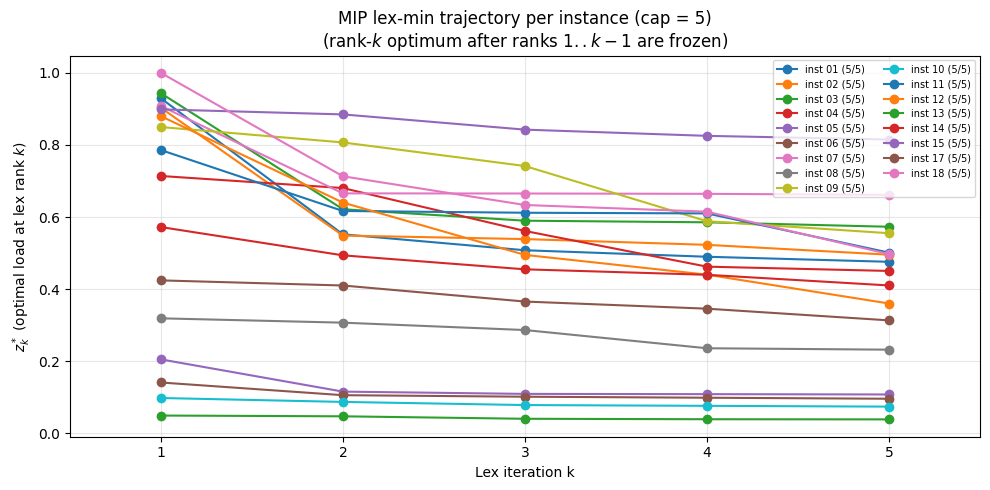

inst    rank            H1           MIP        H1-MIP       %  note
----------------------------------------------------------------------
01         1      0.742760      0.551953     +0.190807 +25.69%
01         2      0.585832      0.507797     +0.078036 +13.32%
01         3      0.541361      0.489773     +0.051588  +9.53%
01         4      0.507797      0.475735     +0.032061  +6.31%
01         5      0.375231      0.470369     -0.095137 -25.35%
01        10      0.336247      0.457129     -0.120881 -35.95%  * not optimized
01        50      0.041495      0.193668     -0.152173-366.73%  * not optimized

02         1      0.321408      0.903075     -0.581667-180.97%
02         2      0.315001      0.522808     -0.207807 -65.97%
02         3      0.310931      0.495467     -0.184536 -59.35%
02         4      0.285011      0.482258     -0.197248 -69.21%
02         5      0.274648      0.473310     -0.198662 -72.33%
02        10      0.223549      0.418416     -0.194867 -87.17%  * not

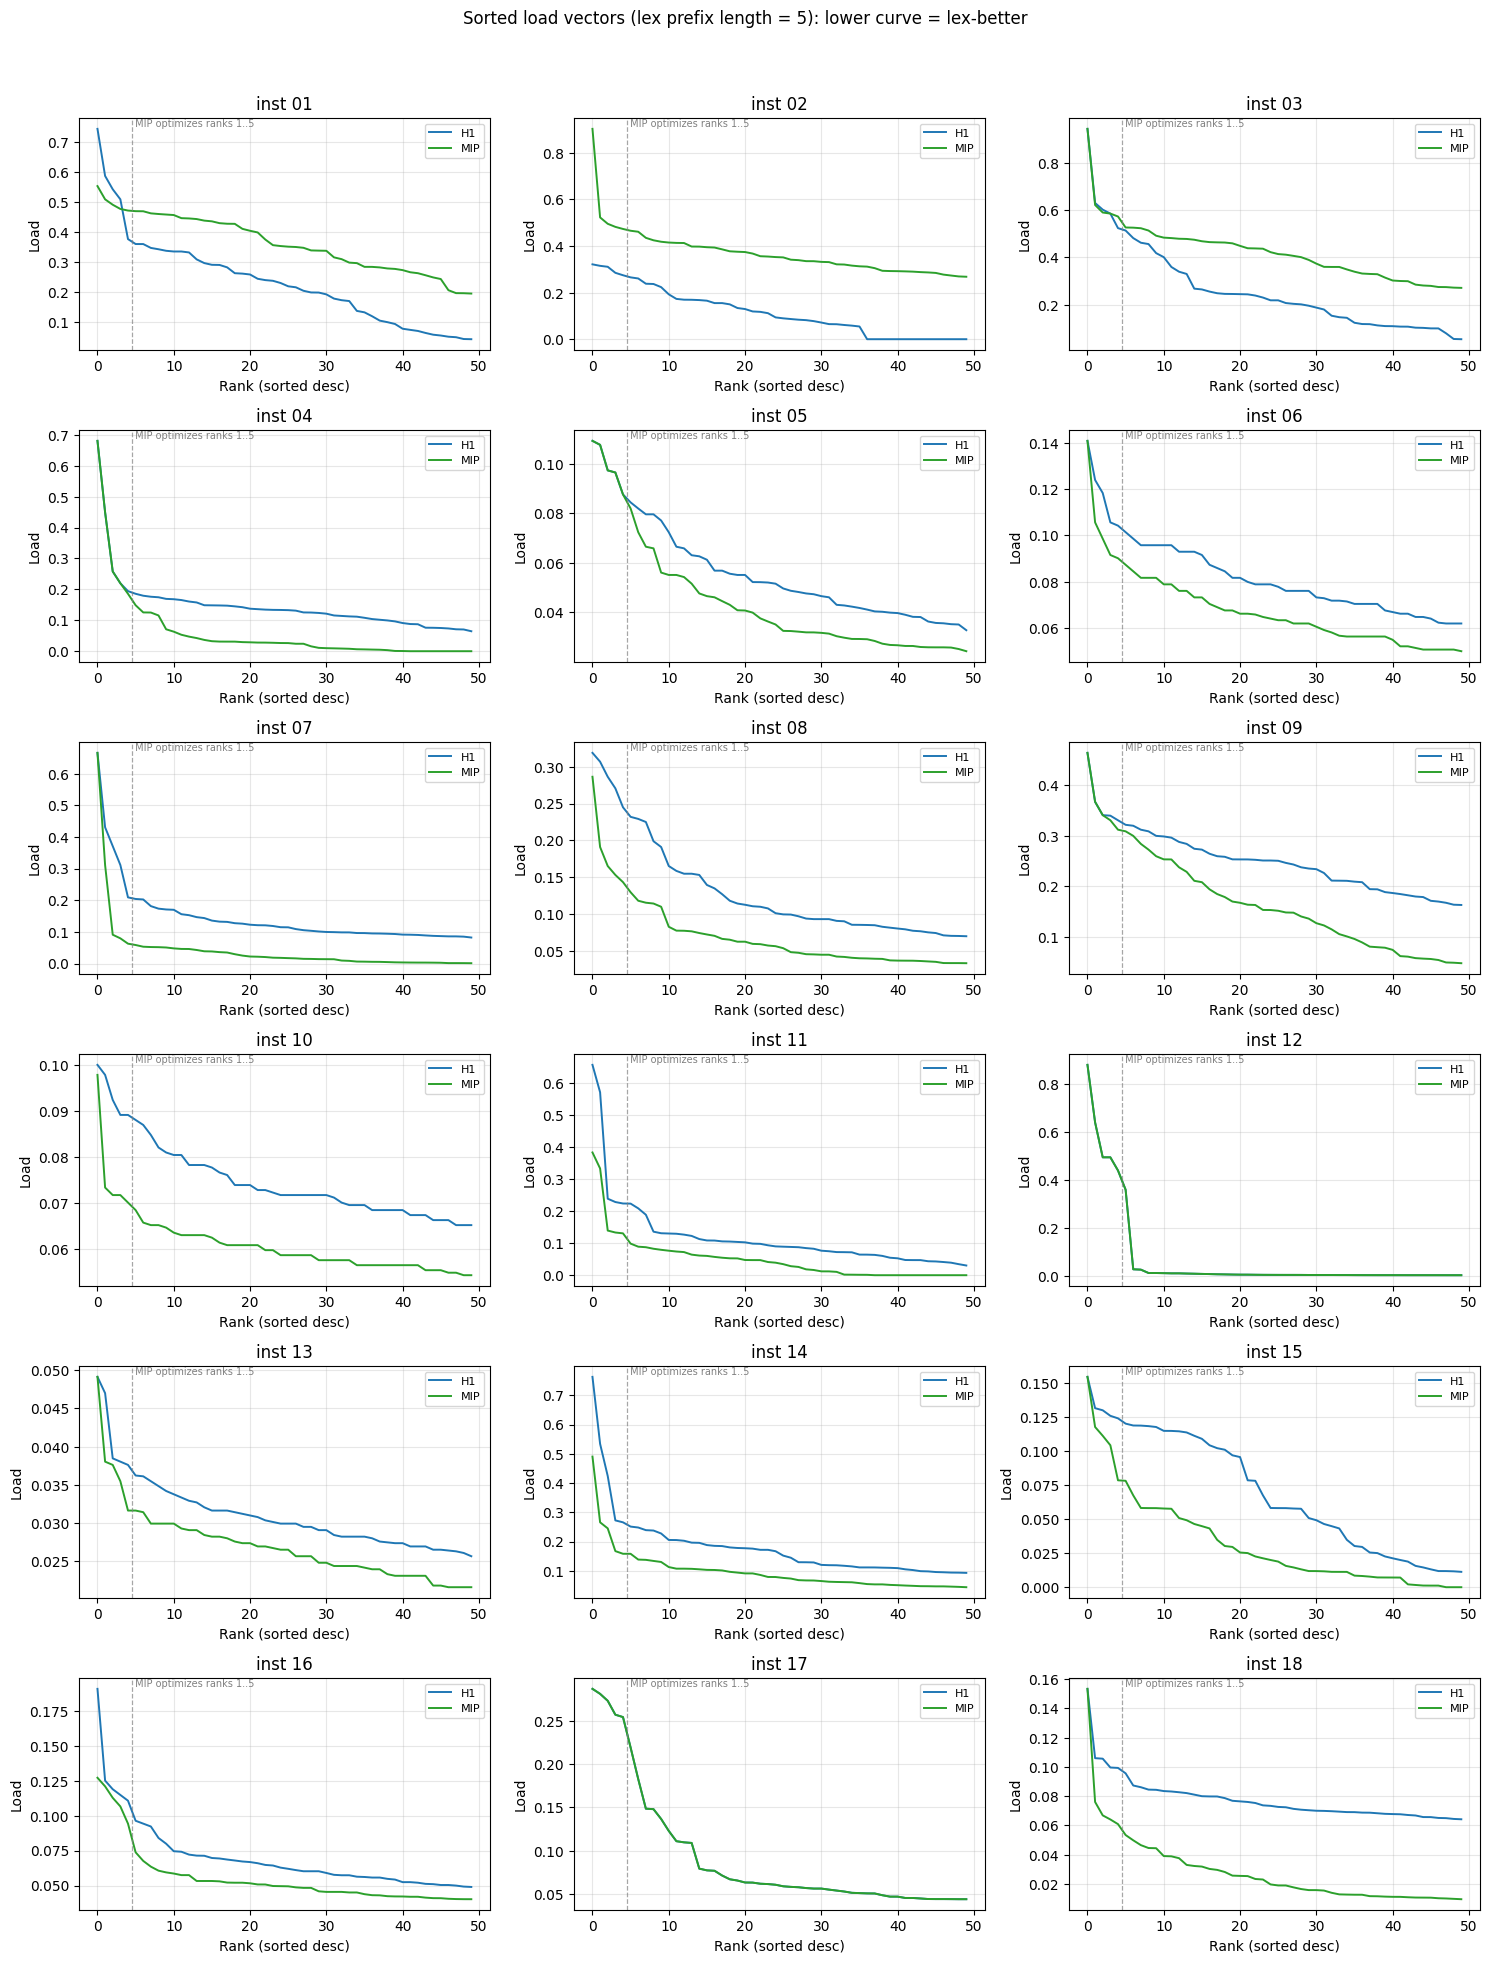

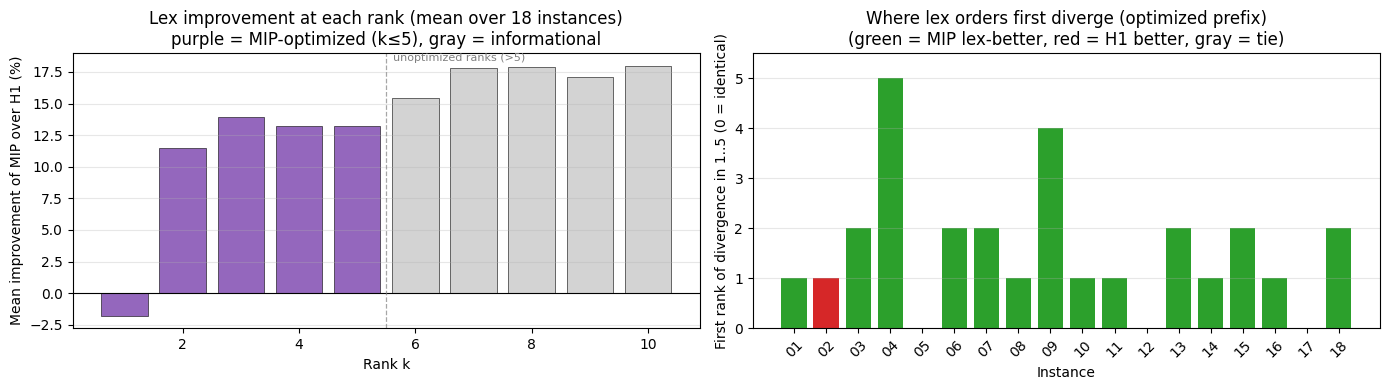

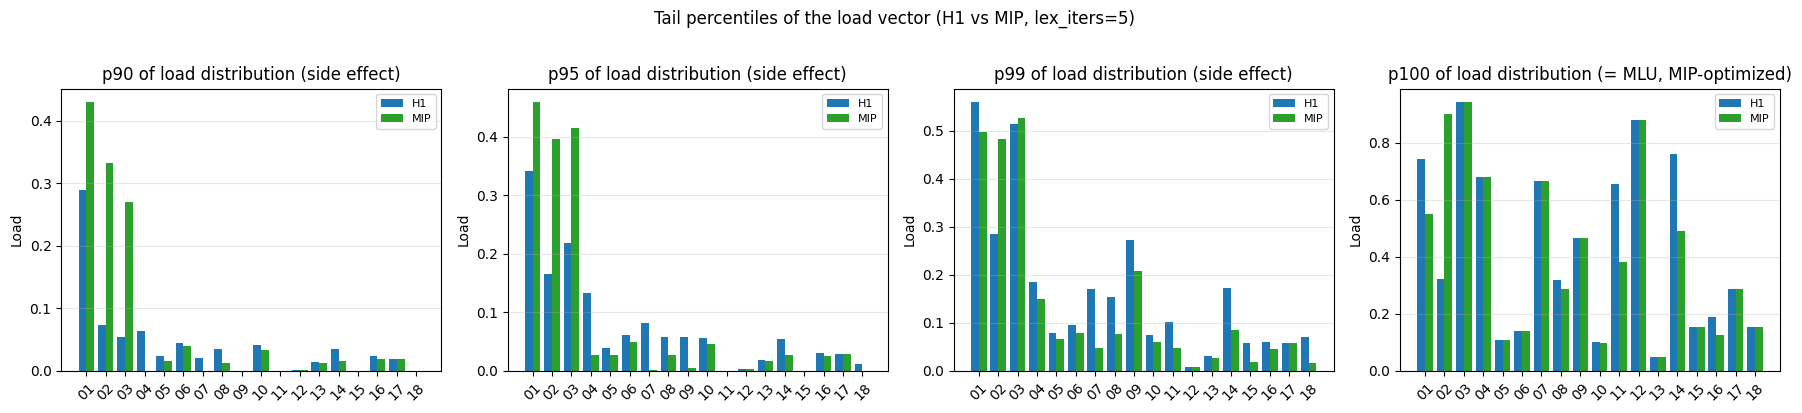

In [14]:
# ============================================================
# Lex-order performance analysis (run AFTER the pipeline so that
# `summary`, outDirH1 and outDirMIP exist on disk).
#
# Tuned for lex_iters = 5: the MIP only optimizes ranks 1..5 of the
# sorted load vector. Ranks beyond 5 are *unoptimized* (free to take
# any value compatible with frozen rank 1..5), so we keep them in the
# plots for context but mark them clearly as informational.
#
# What this cell adds on top of the MLU-only plots above:
#   1. plotLexProgression       - z_k* sequence inside each MIP run
#   2. lexAnalysisTable         - top-k loads (H1 vs MIP) per instance
#   3. plotSortedLoadVectors    - full sorted load vector per instance
#   4. plotLexDominance         - mean lex improvement per rank +
#                                 first rank where the two diverge
#   5. plotTailPercentiles      - p90 / p95 / p99 / p100 load comparison
# ============================================================

# These imports are already done in earlier cells, kept here so the
# cell is self-contained when re-run in isolation.
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Match the lex_iters used by the pipeline. The MIP only optimizes
# the top LEX_ITERS ranks of the sorted load vector; anything past
# this is unoptimized and shown for context only.
LEX_ITERS = 5


def getSortedLoads(datasetPath, instance, outDir):
    """Re-run the python checker on a saved srpaths file and return
    the full sorted (descending) load vector."""
    net, scenario, tm = loadInstance(datasetPath, instance)
    V, A, c, q_arc, D, T, s_d, t_d, v_d, pairs, maxSeg, kappla = buildInstanceData(
        net, scenario, tm)
    r = computeSplitCoefFast(A, T, V, q_arc, net) if USE_FAST_SPLITCOEF \
        else computeSplitCoef(pairs, A, T, V, q_arc, net)
    seg_arcs = precomputeSegArcs(r)

    with open(f"{outDir}/setA-{instance}-srpaths.json") as f:
        srpaths = json.load(f)["srpaths"]

    x_seg = {(d, time): [] for d in D for time in T}
    for entry in srpaths:
        d, time, w = entry["d"], entry["t"], entry["w"]
        sd, td = s_d[d], t_d[d]
        prev = sd; path = []
        for nxt in (w + [td]):
            path.append((prev, nxt)); prev = nxt
        x_seg[(d, time)] = path

    flow = initFlow(A, T)
    for (d, time), path in x_seg.items():
        q_set = set(q_arc.get(time, []))
        addPathFlow(flow, path, time, v_d[(d, time)], seg_arcs, q_set)

    loads = []
    for time in T:
        q_set = set(q_arc.get(time, []))
        for a in A:
            if a not in q_set:
                loads.append(flow[(a, time)] / c[a])
    loads.sort(reverse=True)
    return np.array(loads)


def plotLexProgression(summary):
    """z_k* trajectory across MIP lex iterations - one line per instance.
    A flat line means lex stopped after rank 0 (MLU only). With
    lex_iters = LEX_ITERS, each curve has at most LEX_ITERS points."""
    rows = [r for r in summary if r.get('mip_lex_zs')]
    if not rows:
        print("No lex iteration data in summary.")
        return
    plt.figure(figsize=(10, 5))
    for r in rows:
        zs = r['mip_lex_zs']
        plt.plot(range(1, len(zs) + 1), zs, marker='o',
                 label=f"inst {r['instance']} ({len(zs)}/{LEX_ITERS})")
    plt.xlabel('Lex iteration k')
    plt.ylabel(r'$z_k^*$ (optimal load at lex rank $k$)')
    plt.title(f'MIP lex-min trajectory per instance (cap = {LEX_ITERS})\n'
              '(rank-$k$ optimum after ranks $1..k-1$ are frozen)')
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.xlim(0.5, LEX_ITERS + 0.5)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=7, ncol=2)
    plt.tight_layout(); plt.show()


def lexAnalysisTable(datasetPath, summary, outDirH1, outDirMIP,
                     ranks=(1, 2, 3, 4, 5, 10, 50)):
    """Print top-k loads at the requested ranks for H1 vs MIP, plus the
    aggregate (mean) across instances. Ranks 1..LEX_ITERS are what the
    MIP actually optimized; higher ranks are shown for context only
    and are marked with a star in the output."""
    print(f"{'inst':<6}{'rank':>6}{'H1':>14}{'MIP':>14}"
          f"{'H1-MIP':>14}{'%':>8}  note")
    print("-" * 70)
    aggregate = {k: [] for k in ranks}

    for r in summary:
        inst = r['instance']
        try:
            l1 = getSortedLoads(datasetPath, inst, outDirH1)
            l2 = getSortedLoads(datasetPath, inst, outDirMIP)
        except (FileNotFoundError, KeyError):
            print(f"{inst:<6}  (output files missing - skipped)")
            continue
        for k in ranks:
            if k > min(len(l1), len(l2)):
                continue
            v1 = float(l1[k-1]); v2 = float(l2[k-1])
            d  = v1 - v2
            pct = (100.0 * d / v1) if v1 > 0 else 0.0
            note = "" if k <= LEX_ITERS else "  * not optimized"
            print(f"{inst:<6}{k:>6}{v1:>14.6f}{v2:>14.6f}"
                  f"{d:>+14.6f}{pct:>+7.2f}%{note}")
            aggregate[k].append((v1, v2))
        print()

    print("AGGREGATE (mean across instances)")
    print(f"{'rank':>6}{'mean H1':>14}{'mean MIP':>14}{'mean %':>10}  note")
    print("-" * 56)
    for k in ranks:
        vals = aggregate[k]
        if not vals:
            continue
        m1 = float(np.mean([v[0] for v in vals]))
        m2 = float(np.mean([v[1] for v in vals]))
        pct = 100.0 * (m1 - m2) / m1 if m1 > 0 else 0.0
        note = "" if k <= LEX_ITERS else "  * not optimized"
        print(f"{k:>6}{m1:>14.6f}{m2:>14.6f}{pct:>+9.2f}%{note}")


def plotSortedLoadVectors(datasetPath, summary, outDirH1, outDirMIP,
                          top_n=None, ncols=3):
    """One subplot per instance with H1 and MIP sorted load vectors.
    Curves that lie strictly below another are lex-better (on the
    optimized prefix). A dashed vertical line marks rank LEX_ITERS:
    everything to its left is what the MIP actually optimized."""
    rows = []
    for r in summary:
        try:
            l1 = getSortedLoads(datasetPath, r['instance'], outDirH1)
            l2 = getSortedLoads(datasetPath, r['instance'], outDirMIP)
            rows.append((r['instance'], l1, l2))
        except (FileNotFoundError, KeyError):
            continue
    if not rows:
        print("No load files found.")
        return

    n = len(rows)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(5 * ncols, 3.2 * nrows),
                             squeeze=False)
    for idx, (inst, l1, l2) in enumerate(rows):
        ax = axes[idx // ncols][idx % ncols]
        m = top_n if top_n else max(len(l1), len(l2))
        ax.plot(l1[:m], color='tab:blue',  linewidth=1.4, label='H1')
        ax.plot(l2[:m], color='tab:green', linewidth=1.4, label='MIP')
        # Mark the boundary between optimized and unoptimized ranks.
        if LEX_ITERS < m:
            ax.axvline(LEX_ITERS - 0.5, color='gray', linestyle='--',
                       linewidth=0.9, alpha=0.7)
            ax.text(LEX_ITERS - 0.5, ax.get_ylim()[1],
                    f' MIP optimizes ranks 1..{LEX_ITERS}',
                    fontsize=7, color='gray', va='top')
        ax.set_xlabel('Rank (sorted desc)')
        ax.set_ylabel('Load')
        ax.set_title(f'inst {inst}')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    for k in range(n, nrows * ncols):
        axes[k // ncols][k % ncols].axis('off')
    plt.suptitle(f'Sorted load vectors (lex prefix length = {LEX_ITERS}): '
                 f'lower curve = lex-better',
                 y=1.02)
    plt.tight_layout(); plt.show()


def plotLexDominance(datasetPath, summary, outDirH1, outDirMIP,
                     max_rank=None):
    """Two diagnostics for the lex-vs-MLU question:
       - Left:  mean improvement (%) at every rank k=1..max_rank, averaged
                over instances. With lex_iters=LEX_ITERS we focus on the
                first LEX_ITERS+a few ranks; deeper ranks are unoptimized.
       - Right: first rank where the H1 and MIP load vectors disagree -
                shows whether they tie at MLU and only diverge deeper in
                the optimized prefix.
    """
    if max_rank is None:
        # Default: optimized prefix + a small unoptimized buffer for context.
        max_rank = LEX_ITERS + 5

    inst_data = []
    for r in summary:
        try:
            l1 = getSortedLoads(datasetPath, r['instance'], outDirH1)
            l2 = getSortedLoads(datasetPath, r['instance'], outDirMIP)
            inst_data.append((r['instance'], l1, l2))
        except (FileNotFoundError, KeyError):
            continue
    if not inst_data:
        print("No load data.")
        return

    K = min(min(len(l1), len(l2)) for _, l1, l2 in inst_data)
    K = min(K, max_rank)
    pct_per_rank = np.zeros(K)
    for _, l1, l2 in inst_data:
        for k in range(K):
            v1 = l1[k]
            if v1 > 0:
                pct_per_rank[k] += 100.0 * (v1 - l2[k]) / v1
    pct_per_rank /= len(inst_data)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ranks_axis = np.arange(1, K + 1)
    axes[0].bar(ranks_axis, pct_per_rank,
                color=['tab:purple' if k <= LEX_ITERS else 'lightgray'
                       for k in ranks_axis],
                edgecolor='black', linewidth=0.4)
    axes[0].axhline(0, color='black', linewidth=0.8)
    if LEX_ITERS < K:
        axes[0].axvline(LEX_ITERS + 0.5, color='gray', linestyle='--',
                        linewidth=0.9, alpha=0.7)
        axes[0].text(LEX_ITERS + 0.5, axes[0].get_ylim()[1],
                     f'  unoptimized ranks (>{LEX_ITERS})',
                     fontsize=8, color='gray', va='top')
    axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[0].set_xlabel('Rank k')
    axes[0].set_ylabel('Mean improvement of MIP over H1 (%)')
    axes[0].set_title(f'Lex improvement at each rank (mean over '
                      f'{len(inst_data)} instances)\n'
                      f'purple = MIP-optimized (k≤{LEX_ITERS}), '
                      f'gray = informational')
    axes[0].grid(True, alpha=0.3, axis='y')

    # Right plot: first rank of divergence, restricted to the optimized
    # prefix so the answer is interpretable.
    K_opt = min(LEX_ITERS, K)
    inst_labels, first_diff, signs = [], [], []
    for inst, l1, l2 in inst_data:
        diff_idx = np.where(np.abs(l1[:K_opt] - l2[:K_opt]) > 1e-9)[0]
        if len(diff_idx) == 0:
            inst_labels.append(inst); first_diff.append(0); signs.append(0)
        else:
            k0 = int(diff_idx[0])
            inst_labels.append(inst); first_diff.append(k0 + 1)
            signs.append(1 if l1[k0] > l2[k0] else -1)
    colors = ['tab:green' if s == 1 else
              ('tab:red' if s == -1 else 'tab:gray') for s in signs]
    axes[1].bar(inst_labels, first_diff, color=colors)
    axes[1].set_ylim(0, LEX_ITERS + 0.5)
    axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))
    axes[1].set_xlabel('Instance')
    axes[1].set_ylabel(f'First rank of divergence in 1..{LEX_ITERS} '
                       f'(0 = identical)')
    axes[1].set_title('Where lex orders first diverge (optimized prefix)\n'
                      '(green = MIP lex-better, red = H1 better, gray = tie)')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, axis='y', alpha=0.3)

    plt.tight_layout(); plt.show()


def plotTailPercentiles(datasetPath, summary, outDirH1, outDirMIP,
                        percentiles=(90, 95, 99, 100)):
    """Per-percentile load bars (H1 vs MIP). p100 is just the MLU and
    matches the existing MLU plot. With lex_iters=LEX_ITERS the MIP only
    optimizes the very top of the distribution; p<100 measures the tail
    that the MIP did NOT directly optimize, so any improvement there is
    a side effect of the rank-1..LEX_ITERS solve."""
    inst_data = []
    for r in summary:
        try:
            l1 = getSortedLoads(datasetPath, r['instance'], outDirH1)
            l2 = getSortedLoads(datasetPath, r['instance'], outDirMIP)
            inst_data.append((r['instance'], l1, l2))
        except (FileNotFoundError, KeyError):
            continue
    if not inst_data:
        print("No load data.")
        return

    fig, axes = plt.subplots(1, len(percentiles),
                             figsize=(4.5 * len(percentiles), 4),
                             squeeze=False)
    for idx, p in enumerate(percentiles):
        ax = axes[0][idx]
        labels, v1s, v2s = [], [], []
        for inst, l1, l2 in inst_data:
            labels.append(inst)
            v1s.append(np.percentile(l1, p))
            v2s.append(np.percentile(l2, p))
        x = np.arange(len(labels)); w = 0.4
        ax.bar(x - w/2, v1s, w, label='H1',  color='tab:blue')
        ax.bar(x + w/2, v2s, w, label='MIP', color='tab:green')
        ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45)
        ax.set_ylabel('Load')
        title_suffix = ' (= MLU, MIP-optimized)' if p == 100 \
                       else ' (side effect)'
        ax.set_title(f'p{p} of load distribution{title_suffix}')
        ax.grid(True, axis='y', alpha=0.3)
        ax.legend(fontsize=8)
    plt.suptitle(f'Tail percentiles of the load vector (H1 vs MIP, '
                 f'lex_iters={LEX_ITERS})', y=1.02)
    plt.tight_layout(); plt.show()


# ------------------------------------------------------------
# Run the analysis.
# ------------------------------------------------------------
plotLexProgression(summary)
lexAnalysisTable("../setA", summary, "../outputSetA_h1", "../outputSetA_mip")
plotSortedLoadVectors("../setA", summary, "../outputSetA_h1", "../outputSetA_mip", top_n=50)
plotLexDominance("../setA", summary, "../outputSetA_h1", "../outputSetA_mip")
plotTailPercentiles("../setA", summary, "../outputSetA_h1", "../outputSetA_mip")